# PREPROCESSOR DEMO FOR EXPERIMENT 2

We laid out the planning for Experiment 2, with the overall theme of this collection of experiments is the Transformer architecture.
Our objective is to observe how the differences in sub-architecture impact accuracy. Likewise, the same logic is applied to the preprocessors, whose application varies depending on the subexperiment.
 
We are going to look into 2 preprocessors using in Exp.2.a and Exp.2.b respectively.

In [1]:
import sys
sys.path.append('../../')
from PreprocessingMethods import StandardPreprocessor, DWTPreprocessor
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from copy import deepcopy
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
from IPython.display import clear_output
import matplotlib
clear_output()

In [2]:
df = pd.read_csv("hf://datasets/CitrusBoy/EnergyPriceForecasting/final_dataset_full_clean_with_gas_no_processing.csv")
df["time"] = pd.to_datetime(df["time"])
clear_output()

# Standard Preprocessor

This is how the Standard Preprocessor (yes, the one mentioned on the proposal) to be used on Exp 2.

The standard processor applies simple processing on the data. For floating points, it applies a standard scaler, and a MinMax scaler. For datetime data, it applies Cyclical Scaling.

## Standard Scaler
The standard scaler simply uses Standard Normal Distribution to normalise the values. This helps with uneven scales within the dataset. So the mean of each column becomes 0 and the standard deviation becomes 1. The MinMaxScaler scales the data in a max to min scale. So the minimum value is 0 (or -1 if there are negative values for that feature) and the max value becomes 1.

Both are used because, while standard scaling is useful for baseline detection, the MinMax Scaler ensures that we dont lose outlier feedback.

## Cyclical Scaling
This scaling technique is used for date and time, and its purpose is to enforce the circular dimention of time onto the data, using trigonometry. This scaler reinforces the seasonality of the dataset.

In [3]:
X = df.drop("price", axis=1)

# there would be a y in the real case

In [4]:
st = StandardPreprocessor()

X = st.transform(X)

In [5]:
X.head()

,temperature_2m,cloud_cover,wind_speed_10m,shortwave_radiation,total_load,generation_forecast,Price,Open,High,Low,...,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,quarter_sin,quarter_cos,weekend_sin,weekend_cos
0,0.275260,0.920,0.232164,0.0,0.459870,0.030112,NaN,NaN,NaN,NaN,...,-0.258819,0.965926,-0.781831,0.62349,0.5,0.866025,1.0,6.123234e-17,1.224647e-16,-1.0
1,0.271102,0.872,0.242576,0.0,0.419696,0.033842,NaN,NaN,NaN,NaN,...,0.000000,1.000000,0.000000,1.00000,0.5,0.866025,1.0,6.123234e-17,0.000000e+00,1.0
2,0.270686,0.706,0.253760,0.0,0.390513,0.038698,NaN,NaN,NaN,NaN,...,0.258819,0.965926,0.000000,1.00000,0.5,0.866025,1.0,6.123234e-17,0.000000e+00,1.0
3,0.271518,0.244,0.258774,0.0,0.377381,0.046702,NaN,NaN,NaN,NaN,...,0.500000,0.866025,0.000000,1.00000,0.5,0.866025,1.0,6.123234e-17,0.000000e+00,1.0
4,0.270686,0.406,0.258774,0.0,0.372970,0.054745,NaN,NaN,NaN,NaN,...,0.707107,0.707107,0.000000,1.00000,0.5,0.866025,1.0,6.123234e-17,0.000000e+00,1.0


In [6]:
X.describe()

,temperature_2m,cloud_cover,wind_speed_10m,shortwave_radiation,total_load,generation_forecast,Price,Open,High,Low,...,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,quarter_sin,quarter_cos,weekend_sin,weekend_cos
count,96133.000000,96133.000000,96133.000000,96133.000000,96133.000000,96133.000000,49488.000000,49488.000000,49488.000000,49488.000000,...,96133.000000,9.613300e+04,96133.000000,96133.000000,9.613300e+04,9.613300e+04,9.613300e+04,9.613300e+04,9.613300e+04,96133.000000
mean,0.478215,0.668799,0.240067,0.145746,0.556883,0.172929,0.114258,0.113726,0.114952,0.112734,...,-0.000060,-9.944924e-05,0.000590,0.000590,-6.602035e-03,-2.887859e-03,-6.844684e-03,3.255906e-03,3.493440e-17,0.429478
std,0.137524,0.319590,0.128979,0.221190,0.118048,0.162676,0.126408,0.126301,0.126960,0.125723,...,0.707131,7.070897e-01,0.707068,0.707152,7.057543e-01,7.084273e-01,7.059841e-01,7.081944e-01,5.529783e-17,0.903082
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000e+00,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00,-1.000000
25%,0.375884,0.430000,0.141149,0.000000,0.481716,0.052298,0.043136,0.042504,0.042464,0.042822,...,-0.707107,-7.071068e-01,-0.781831,-0.900969,-8.660254e-01,-8.660254e-01,-1.000000e+00,-1.836970e-16,0.000000e+00,-1.000000
50%,0.473181,0.758000,0.216352,0.006545,0.544884,0.121031,0.076709,0.076491,0.077435,0.075150,...,0.000000,-1.836970e-16,0.000000,-0.222521,-2.449294e-16,-1.836970e-16,-2.449294e-16,-1.836970e-16,0.000000e+00,1.000000
75%,0.578378,0.974000,0.313536,0.229519,0.635310,0.244744,0.117872,0.117513,0.119727,0.115641,...,0.707107,7.071068e-01,0.781831,0.623490,5.000000e-01,8.660254e-01,1.224647e-16,1.000000e+00,1.224647e-16,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000e+00,0.974928,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.224647e-16,1.000000


# Discrete Wavelet Transform

A Discrete Wavelet Transform preprocessor is used for decomposing the signal into more nieche frequencies. This technique allows for nitpicking which "bands" or "signals" we want to remove, either because they capture a patter we want to obscure, or are just noise that the model can do nothing with.

Initially, we wrote down in the proposal that we would use Fast Fourier Transform, but for time-series data, the wavelet transform is more useful. The amplitude of the signal is not as useful as the decomposition of said signal, since it will allow us to reduce noise for some features, while preserving the overall patterns.

In [7]:
cutoff_date = df[df['Price'].isna() == False]['time'].iloc[0]

In [8]:
df = df[df['time'] > cutoff_date]

df.interpolate(method='linear', inplace=True)
clear_output()

In [9]:
dwt = DWTPreprocessor()

df_dwt = dwt.transform(df)

In [10]:
_dimensionGroups= [['temperature_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation'], ['total_load', 'generation_forecast', 'Price', 'High', 'Low', 'Change %', 'price']]

This plot simply shows the unprocessed signals

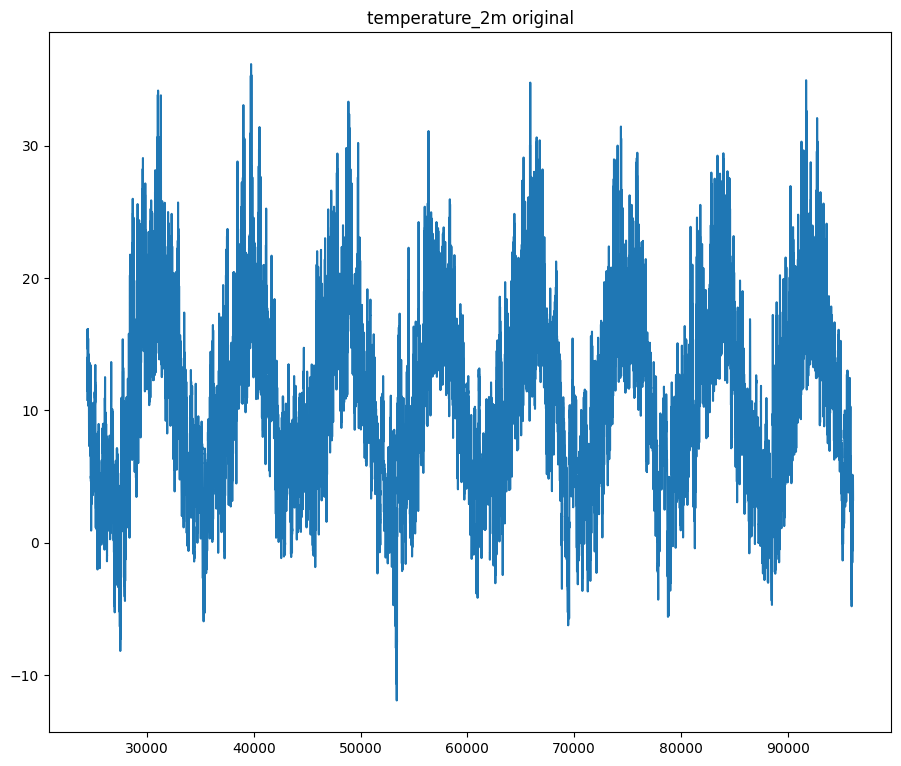

In [11]:
plt.figure(figsize=(50, 20))
for i, group in enumerate(_dimensionGroups):
    for j, name in enumerate(group):
        if name == "temperature_2m":
            plt.subplot(len(_dimensionGroups), len(group), i*len(group) + j + 1)
            plt.plot(df_dwt[name])
            plt.title(name + " original")

# SIGNAL DECOMPOSITION
In comparison with the plots above, the plot below is already the decomposition of the original signal into 3 bands denominated as $d_n$. We can analyse each one to see which ones show noise, and which ones show a recognisable pattern.

## TODO: Feature Selection based on noise. Which Decompositions we want to keep

for what its worth, cloud_cover should just dissapear. it is pointless noise which we know from EDA is not statistically significant. At the very least, not decomposition feature from cloud cover should be included.

for temp, d2 and d3 looks ok. maybe drop d1

for wind, d2 (maybe), should be tested with, seems fairly useless

shortwave radiation looks sctuctured on both signals, but especially d3, so again, d2 and d3

for total_load, d3 and maybe d2. same for gen_forecast


Change%, their decomposition can be dropped

If we really want to try-hard this, we could totally do hyperparameter tunning but it could take like a week if we automate the process xD although... this would be better option

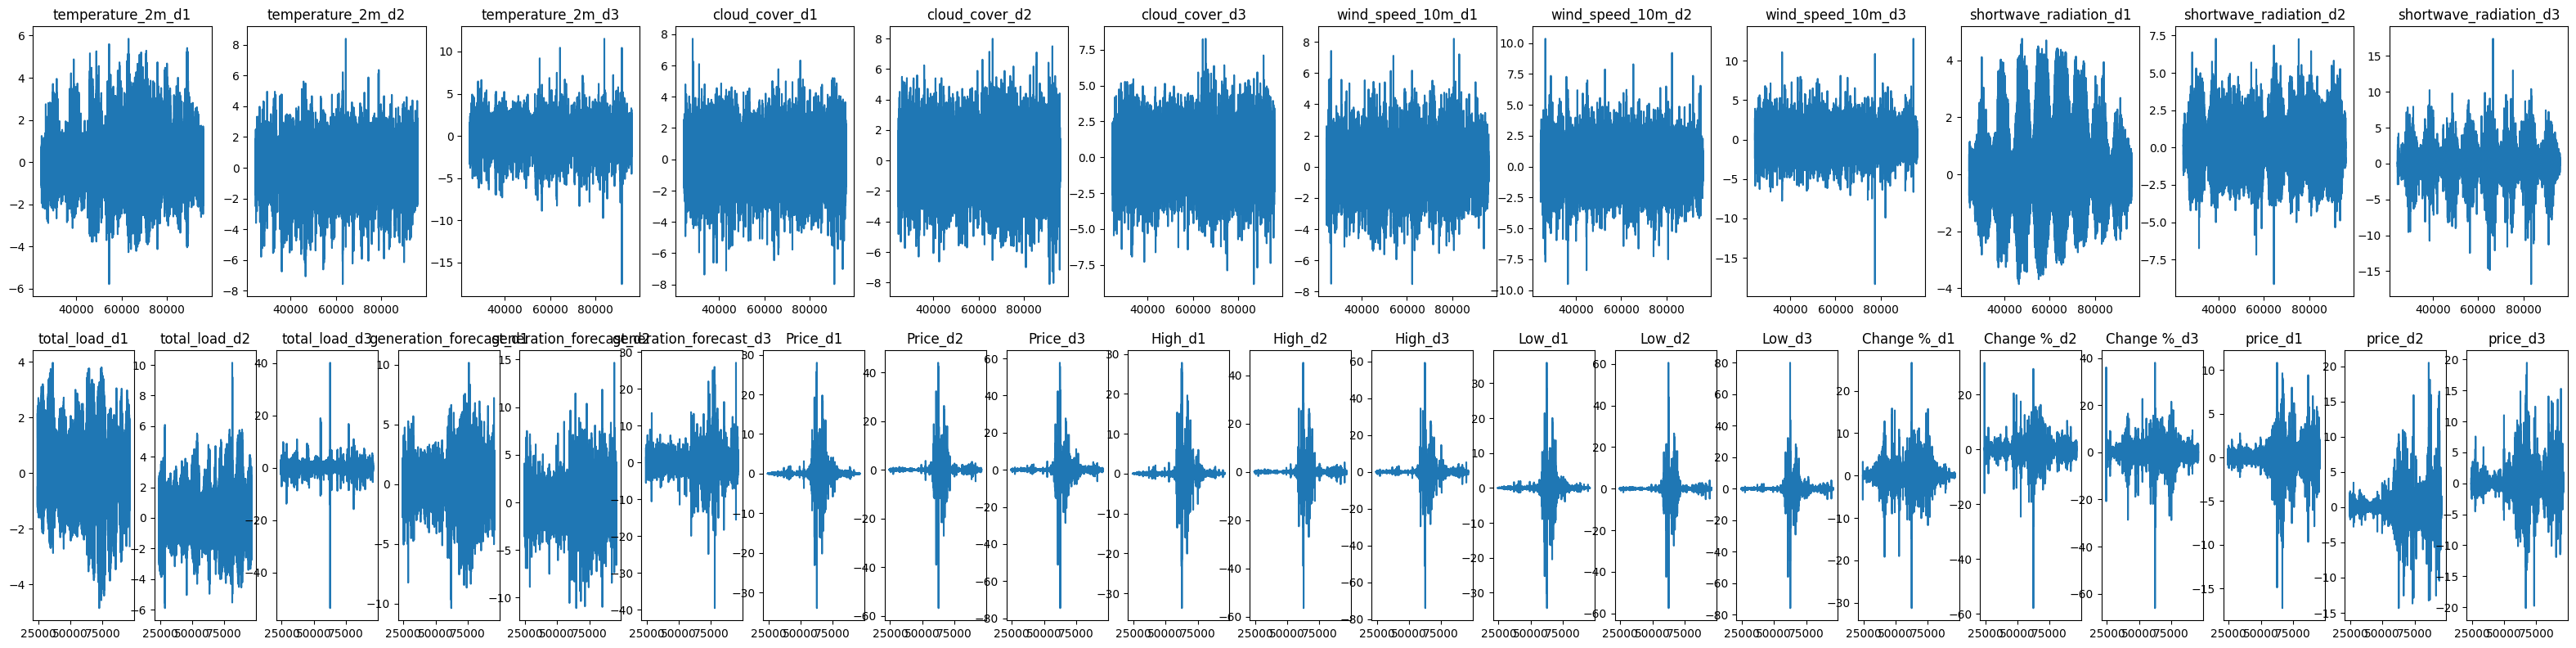

In [12]:
plt.figure(figsize=(40, 30))
for i, group in enumerate(_dimensionGroups):
    for j, name in enumerate(group):
        for id in range(1, 4):
            plt.subplot(len(_dimensionGroups)*3, len(group)*3, i*len(group)*3 + j*3 + id)
            plt.plot(df_dwt[name + f'_d{id}'])
            plt.title(name + f'_d{id}')

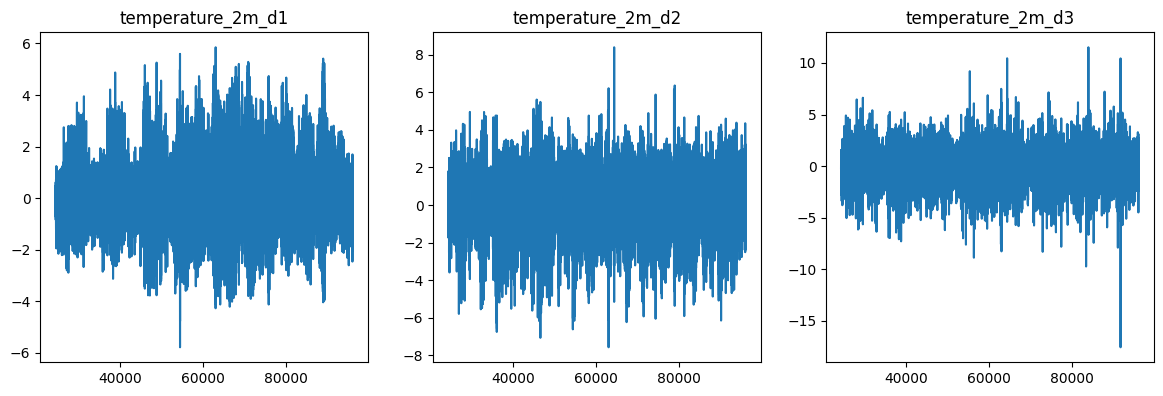

In [13]:
plt.figure(figsize=(60, 30))
for i, group in enumerate(_dimensionGroups):
    for j, name in enumerate(group):
        if name == "temperature_2m":
            for id in range(1, 4):
                plt.subplot(len(_dimensionGroups)*3, len(group)*3, i*len(group)*3 + j*3 + id)
                plt.plot(df_dwt[name + f'_d{id}'])
                plt.title(name + f'_d{id}')

In [14]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'sans-serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})


In [15]:
plt.savefig("temperatureDecomposition.pgf", bbox_inches="tight")

## Ablation

Ablation is when you remove a feature from the overall system and you observe the differences that the removal produces. That analysis might yield the conclusion that a particular feature should not be included in the overall model.

In [16]:
for col in df_dwt.columns:
    if col != "price" and col != "time":
        for lag in range(1, 25): 
            df_dwt[f"{col}_lag{lag}"] = df_dwt[col].shift(lag)

df_dwt['target'] = df_dwt['price'].shift(-24)
clear_output()

In [17]:
non_lag_cols = [c for c in df_dwt.columns if '_lag' not in c and c not in ['target', 'time']]
df_dwt = df_dwt.drop(columns=non_lag_cols)
df_dwt = df_dwt.dropna().reset_index(drop=True)

In [18]:
train = df_dwt.iloc[:int(len(df_dwt)*0.7)]
val   = df_dwt.iloc[int(len(df_dwt)*0.7):int(len(df_dwt)*0.85)]
test  = df_dwt.iloc[int(len(df_dwt)*0.85):]

X_train = train.drop(columns=['target', 'time'])
y_train = train['target']
X_val = val.drop(columns=['target', 'time'])
y_val = val['target']

In [19]:
def train_eval(X_train, y_train, X_val, y_val):
    model = LGBMRegressor(n_estimators=300, learning_rate=0.05)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    rmse = mean_squared_error(y_val, preds) ** 0.5
    return rmse, model

In [20]:
baseline_rmse, baseline_model = train_eval(
    X_train, y_train, X_val, y_val
)
clear_output()

baseline_rmse

33.506869817188644

### per feature

In [21]:
def ablation_feature(X_train, X_val, y_train, y_val, baseline_rmse):
    results = []

    distinct_features = set([col.split('_')[0] for col in X_train.columns])
    for col in distinct_features:
        cols =[[elem for elem in X_train.columns if col in elem]][0]
        X_train_drop = X_train.drop(columns=cols)
        X_val_drop   = X_val.drop(columns=cols)

        rmse, _ = train_eval(X_train_drop, y_train, X_val_drop, y_val)

        results.append({
            "feature": col,
            "rmse": rmse,
            "delta": rmse - baseline_rmse
        })

    clear_output()
    return pd.DataFrame(results).sort_values("delta", ascending=False)

Temporal features are the most benefitial, followed by temperature (im surprised), price (ah duhh), Low (lowest gas price)(????), total generation. Wind is really far bellow

In [22]:
ablation_feature(X_train, X_val, y_train, y_val, baseline_rmse)

,feature,rmse,delta
1,time,35.445261,1.938391
12,temperature,33.910776,0.403906
10,price,33.818318,0.311448
8,Low,33.765721,0.258851
11,total,33.711366,0.204496
4,shortwave,33.622666,0.115796
6,wind,33.596264,0.089395
2,High,33.536013,0.029143
0,cloud,33.460034,-0.046836
7,Open,33.371525,-0.135344


### per band

In [23]:
def ablation_by_band(X_train, X_val, y_train, y_val, baseline_rmse):
    bands = {
        "d1": [c for c in X_train.columns if "_d1" in c],
        "d2": [c for c in X_train.columns if "_d2" in c],
        "d3": [c for c in X_train.columns if "_d3" in c],
    }

    results = []

    for band, cols in bands.items():
        if not cols:
            continue

        X_train_drop = X_train.drop(columns=cols)
        X_val_drop   = X_val.drop(columns=cols)

        rmse, _ = train_eval(X_train_drop, y_train, X_val_drop, y_val)

        results.append({
            "band": band,
            "rmse": rmse,
            "delta": rmse - baseline_rmse,
            "n_features_removed": len(cols)
        })

    clear_output()

    return pd.DataFrame(results).sort_values("delta", ascending=False)

Seems like d2 is the likely better one

In [24]:
ablation_by_band(X_train, X_val, y_train, y_val, baseline_rmse)

,band,rmse,delta,n_features_removed
1,d2,33.473964,-0.032906,264
0,d1,33.455149,-0.051721,264
2,d3,33.412654,-0.094216,264


## per variable

In [25]:
def ablation_per_variable_band(X_train, X_val, y_train, y_val, baseline_rmse):
    results = []

    base_vars = set([c.split("_d")[0] for c in X_train.columns if "_d" in c])

    for var in base_vars:
        for band in ["d1", "d2", "d3"]:
            cols = [c for c in X_train.columns if c.startswith(var) and f"_{band}" in c]

            if not cols:
                continue

            X_train_drop = X_train.drop(columns=cols)
            X_val_drop   = X_val.drop(columns=cols)

            rmse, _ = train_eval(X_train_drop, y_train, X_val_drop, y_val)

            results.append({
                "variable": var,
                "band": band,
                "rmse": rmse,
                "delta": rmse - baseline_rmse
            })

    clear_output()

    return pd.DataFrame(results).sort_values("delta", ascending=False)

Ok really interesting stuff here. That total_load, specifically d2, ranked the highest is impressive.

In [26]:
table = ablation_per_variable_band(X_train, X_val, y_train, y_val, baseline_rmse)

In [27]:
table.to_latex("ablationPerVariable.tex", index=False)